# Track C — Causal Patch Ablation
### CS 639 | UW–Madison | ViT Hallucination Research

---

## Hypothesis (revised from Tracks A + B)

Track A found **no signal** in attention geometry (ρ = 0.003, Cohen's d = 0.039 — negligible).  
Track B found **significant signal** in patch feature content: probe accuracy is lower on hallucinating images at all 4 layers tested (p < 0.005, Wilcoxon), with layer 18 as the sweet spot.

**Revised hypothesis:** The ViT encoder's failure on hallucinating images is in *feature content*, not *attention geometry*. Specifically: the patch embeddings at layer 18 encode less object information on images where LLaVA later hallucinates — and this degradation causally contributes to hallucination, not just correlates with it.

**Track C tests causality via two experiments:**

| Experiment | Operation | Question |
|---|---|---|
| **Exp 1 — Ablation** | Zero out top-K / bottom-K / random-K patches at layer 18 | Does removing high-attention patches change hallucination? Bottom-K removal should do nothing if attention is uninformative (consistent with Track A) |
| **Exp 2 — Patch Swap** | Replace top-K patches in hallucinating image with patches from a semantically matched clean image | If patch content is the causal driver, importing clean patches should reduce hallucination rate |

**Key design choices grounded in the data:**
- Intervention happens at **layer 18** (best probe accuracy per Track B, not arbitrary)
- Patch selection by **rollout rank** from Track A (available for all 500 images)
- Swap pairs are **category-matched** (3–7 shared GT objects) to isolate patch content from semantic context change
- Same 500-image COCO pool, same full-precision LLaVA-1.5-7B as Track A — no quantization


In [44]:
!pip install -q "transformers>=4.45.0" accelerate Pillow
!pip install -q statsmodels scipy matplotlib seaborn
print('Done.')

Done.


In [45]:
# ── Cell 2: Upload Track A data ───────────────────────────────────────────────
# Upload these 3 files:
#   rollout_data_complete.npz
#   chair_labels.csv
#   entropy_ranks.csv
from google.colab import files, drive
import os

WORK = '/content/track_c'
os.makedirs(WORK, exist_ok=True)

print('Upload rollout_data_complete.npz, chair_labels.csv, entropy_ranks.csv')
uploaded = files.upload()
for fn, data in uploaded.items():
    with open(f'{WORK}/{fn}', 'wb') as f:
        f.write(data)
print('Uploaded:', os.listdir(WORK))

Upload rollout_data_complete.npz, chair_labels.csv, entropy_ranks.csv


Saving entropy_ranks.csv to entropy_ranks (3).csv
Saving rollout_data_complete.npz to rollout_data_complete (3).npz
Saving chair_labels.csv to chair_labels (3).csv
Uploaded: ['entropy_ranks (1).csv', 'chair_labels (1).csv', 'exp1_ablation_results.csv', 'rollout_data_complete.npz', 'chair_labels (2).csv', 'entropy_ranks (3).csv', 'chair_labels.csv', 'rollout_data_complete (2).npz', 'rollout_data_complete (3).npz', 'rollout_data_complete (1).npz', 'chair_labels (3).csv', 'entropy_ranks.csv', 'entropy_ranks (2).csv']


In [46]:
# ── Cell 3: Load Track A data & build experiment sets ─────────────────────────
import numpy as np
import pandas as pd

chair_df   = pd.read_csv(f'{WORK}/chair_labels.csv')
entropy_df = pd.read_csv(f'{WORK}/entropy_ranks.csv')
npz        = np.load(f'{WORK}/rollout_data_complete.npz', allow_pickle=True)

rollout_ids = npz['image_ids']
rollouts    = npz['rollouts']          # (500, 576)
id_to_rollout = {int(rollout_ids[i]): rollouts[i] for i in range(len(rollout_ids))}

def parse_gt(s):
    if pd.isna(s): return set()
    return set(s.split('|'))

hall_df  = chair_df[chair_df['is_hallucinating'] == True].copy()
clean_df = chair_df[chair_df['is_hallucinating'] == False].copy()
print(f'Hallucinating: {len(hall_df)} | Clean: {len(clean_df)} | Total: {len(chair_df)}')

# ── Build matched pairs for Exp 2 (patch swap) ───────────────────────────────
np.random.seed(42)
clean_list = clean_df.to_dict('records')
best_pairs = []
for _, hrow in hall_df.iterrows():
    h_gt = parse_gt(hrow['gt_objects'])
    candidates = [(crow, len(h_gt & parse_gt(crow['gt_objects'])))
                  for crow in clean_list
                  if len(h_gt & parse_gt(crow['gt_objects'])) > 0
                  and crow['image_id'] in id_to_rollout]
    if not candidates:
        continue
    best_n = max(c[1] for c in candidates)
    best_c = [c[0] for c in candidates if c[1] == best_n]
    partner = best_c[np.random.randint(len(best_c))]
    best_pairs.append({
        'hall_id':  hrow['image_id'],
        'clean_id': partner['image_id'],
        'shared_gt': '|'.join(sorted(h_gt & parse_gt(partner['gt_objects']))),
        'n_shared': best_n,
        'hall_gt':  hrow['gt_objects'],
        'clean_gt': partner['gt_objects'],
        'hall_hallucinated': hrow['hallucinated_objects'],
    })
pairs_df = pd.DataFrame(best_pairs)

# Take top 50 pairs by overlap depth, then pick 50 deterministically
top_pairs = pairs_df.sort_values('n_shared', ascending=False).head(50).reset_index(drop=True)
print(f'Pairs with ≥1 shared GT category: {len(pairs_df)}')
print(f'Top-50 pairs selected (overlap range: {top_pairs["n_shared"].min()}–{top_pairs["n_shared"].max()} categories)')

# ── Exp 1 image set: 50 images (25 hall + 25 clean) ─────────────────────────
exp1_hall  = np.random.choice(hall_df['image_id'].values,  25, replace=False)
exp1_clean = np.random.choice(clean_df['image_id'].values, 25, replace=False)
exp1_ids   = np.concatenate([exp1_hall, exp1_clean])
print(f'Exp 1 image set: {len(exp1_ids)} images ({len(exp1_hall)} hall + {len(exp1_clean)} clean)')

# All unique image IDs needed
all_needed_ids = set(exp1_ids) | set(top_pairs['hall_id']) | set(top_pairs['clean_id'])
print(f'Total unique images to download: {len(all_needed_ids)}')

Hallucinating: 329 | Clean: 171 | Total: 500
Pairs with ≥1 shared GT category: 321
Top-50 pairs selected (overlap range: 3–7 categories)
Exp 1 image set: 50 images (25 hall + 25 clean)
Total unique images to download: 110


In [47]:
# ── Cell 4: Download COCO val2017 images ──────────────────────────────────────
import urllib.request

IMG_DIR = '/content/coco_val2017'
os.makedirs(IMG_DIR, exist_ok=True)

def download_coco_image(img_id):
    fname = f'{int(img_id):012d}.jpg'
    dst   = f'{IMG_DIR}/{fname}'
    if not os.path.exists(dst):
        url = f'http://images.cocodataset.org/val2017/{fname}'
        try:
            urllib.request.urlretrieve(url, dst)
        except Exception as e:
            print(f'  FAILED {img_id}: {e}')
            return False
    return True

print(f'Downloading {len(all_needed_ids)} images...')
ok = 0
for i, img_id in enumerate(sorted(all_needed_ids)):
    if download_coco_image(img_id):
        ok += 1
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(all_needed_ids)} done')
print(f'Downloaded: {ok}/{len(all_needed_ids)}')

  20/110 done
  40/110 done
  60/110 done
  80/110 done
  100/110 done
Downloaded: 110/110


In [48]:
# ── CELLS 5+6+7 COMBINED — run this as ONE new cell ──────────────────────────
import torch, time, os, urllib.request, numpy as np, pandas as pd
from PIL import Image
from transformers import LlavaForConditionalGeneration, AutoProcessor

MODEL_ID = 'llava-hf/llava-1.5-7b-hf'
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map='auto'
)
model.eval()
print('Model on:', next(model.parameters()).device)
print('ViT layers:', len(model.model.vision_tower.vision_model.encoder.layers))

# ── Diagnostic: check exact hook output shape ─────────────────────────────────
PROMPT = 'USER: <image>\nDescribe everything you see in this image in one sentence. ASSISTANT:'
N_PATCHES = 576
INTERVENTION_LAYER = 17

test_img = Image.open(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg').convert('RGB')
inputs_t = processor(text=PROMPT, images=test_img, return_tensors='pt')
inputs_t = {k: v.to(model.device) for k, v in inputs_t.items()}
inputs_t['pixel_values'] = inputs_t['pixel_values'].to(torch.float16)

captured = {}
def diag_hook(module, inp, output):
    captured['type'] = type(output).__name__
    if isinstance(output, tuple):
        captured['n_elements'] = len(output)
        captured['el0_shape'] = tuple(output[0].shape)
        captured['el0_dim'] = output[0].dim()
    else:
        captured['shape'] = tuple(output.shape)
        captured['dim'] = output.dim()

h = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER].register_forward_hook(diag_hook)
with torch.no_grad():
    model.model.vision_tower(inputs_t['pixel_values'])
h.remove()
print('Hook output shape:', captured)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model on: cuda:0
ViT layers: 24
Hook output shape: {'type': 'Tensor', 'shape': (1, 577, 1024), 'dim': 3}


In [49]:
import torch, time, os, urllib.request, numpy as np, pandas as pd
from PIL import Image

PROMPT = 'USER: <image>\nDescribe everything you see in this image in one sentence. ASSISTANT:'
N_PATCHES = 576
INTERVENTION_LAYER = 17
K_ABLATE = 58

# ── Detect layer output shape ─────────────────────────────────────────────────
test_img = Image.open(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg').convert('RGB')
inp = processor(text=PROMPT, images=test_img, return_tensors='pt')
inp = {k: v.to(model.device) for k, v in inp.items()}
inp['pixel_values'] = inp['pixel_values'].to(torch.float16)

_shape = {}
def _shape_hook(module, inp_, out):
    _shape['is_tuple'] = isinstance(out, tuple)
    _shape['shape'] = tuple(out[0].shape) if isinstance(out, tuple) else tuple(out.shape)
_h = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER].register_forward_hook(_shape_hook)
with torch.no_grad():
    model.model.vision_tower(inp['pixel_values'])
_h.remove()
print('Layer output shape:', _shape)

# ── Core helpers ──────────────────────────────────────────────────────────────
def _apply_to_patches(hidden, fn):
    modified = hidden.clone()
    if modified.dim() == 3:
        modified[:, 1:, :] = fn(modified[:, 1:, :])
    else:
        modified[1:, :] = fn(modified[1:, :])
    return modified

def _make_forward_hook(patch_hook):
    def _hook(module, inp, output):
        hidden = output[0] if isinstance(output, tuple) else output
        modified = _apply_to_patches(hidden, patch_hook)
        if isinstance(output, tuple):
            return (modified,) + output[1:]
        return modified
    return _hook

def get_caption(image_path, patch_hook=None):
    img    = Image.open(image_path).convert('RGB')
    inputs = processor(text=PROMPT, images=img, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
    handles = []
    if patch_hook is not None:
        layer = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER]
        handles.append(layer.register_forward_hook(_make_forward_hook(patch_hook)))
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    for h in handles:
        h.remove()
    text = processor.decode(out[0], skip_special_tokens=True)
    return text.split('ASSISTANT:')[-1].strip()

def _mask_hook(mask):
    def hook(patches):
        m = mask.to(patches.device)
        if patches.dim() == 3:
            return patches * m.view(1, -1, 1)
        return patches * m.unsqueeze(-1)
    return hook

def make_zero_topk_hook(rollout_vec, k=K_ABLATE):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.argsort(rollout_vec)[-k:]] = 0.0
    return _mask_hook(mask)

def make_zero_botk_hook(rollout_vec, k=K_ABLATE):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.argsort(rollout_vec)[:k]] = 0.0
    return _mask_hook(mask)

def make_zero_random_hook(k=K_ABLATE, seed=0):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.random.default_rng(seed).choice(N_PATCHES, k, replace=False)] = 0.0
    return _mask_hook(mask)

def make_swap_hook(donor_rollout, donor_image_path, k=K_ABLATE):
    cache = {'patches': None}
    top_idx = np.argsort(donor_rollout)[-k:]

    def prepare_donor():
        if not os.path.exists(donor_image_path):
            print(f'  donor image missing: {donor_image_path}')
            return
        img    = Image.open(donor_image_path).convert('RGB')
        inputs = processor(text=PROMPT, images=img, return_tensors='pt')
        inputs = {kk: v.to(model.device) for kk, v in inputs.items()}
        inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
        _cap = {}
        def _ch(module, inp_, out):
            hidden = out[0] if isinstance(out, tuple) else out
            if hidden.dim() == 3:
                _cap['p'] = hidden[:, 1:, :].detach().clone()
            else:
                _cap['p'] = hidden[1:, :].detach().clone()
        _h = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER].register_forward_hook(_ch)
        with torch.no_grad():
            model.model.vision_tower(inputs['pixel_values'])
        _h.remove()
        if 'p' in _cap:
            cache['patches'] = _cap['p']
        else:
            print(f'  WARNING: capture hook fired but _cap empty for {donor_image_path}')

    def hook(patches):
        if cache['patches'] is None:
            return patches
        modified = patches.clone()
        donor = cache['patches'].to(patches.device)
        if patches.dim() == 3:
            d = donor if donor.dim()==3 else donor.unsqueeze(0)
            modified[:, top_idx, :] = d[:, top_idx, :]
        else:
            d = donor if donor.dim()==2 else donor.squeeze(0)
            modified[top_idx, :] = d[top_idx, :]
        return modified

    return hook, prepare_donor, cache

# ── CHAIR scoring ─────────────────────────────────────────────────────────────
COCO_SYNONYMS = {
    'person':['person','man','woman','boy','girl','people','child','kid','human','gentleman','lady'],
    'bicycle':['bicycle','bike'],'car':['car','automobile','vehicle','sedan','suv','cab','taxi'],
    'motorcycle':['motorcycle','motorbike'],'airplane':['airplane','plane','aircraft','aeroplane','jet'],
    'bus':['bus','coach'],'train':['train','locomotive','subway'],'truck':['truck','lorry','pickup'],
    'boat':['boat','ship','vessel','canoe','kayak','sailboat'],
    'traffic light':['traffic light','stoplight'],'fire hydrant':['fire hydrant','hydrant'],
    'stop sign':['stop sign'],'bench':['bench'],
    'bird':['bird','pigeon','seagull','duck','eagle','owl','crow','sparrow','parrot'],
    'cat':['cat','kitten','feline'],'dog':['dog','puppy','canine'],'horse':['horse','pony'],
    'sheep':['sheep','lamb'],'cow':['cow','cattle','bull'],'elephant':['elephant'],
    'bear':['bear'],'zebra':['zebra'],'giraffe':['giraffe'],
    'backpack':['backpack','bag','knapsack','rucksack'],'umbrella':['umbrella'],
    'handbag':['handbag','purse'],'tie':['tie','necktie'],'suitcase':['suitcase','luggage'],
    'frisbee':['frisbee'],'skis':['skis','ski'],'snowboard':['snowboard'],
    'sports ball':['sports ball','ball','soccer ball','basketball','baseball','football','tennis ball'],
    'kite':['kite'],'baseball bat':['baseball bat','bat'],
    'baseball glove':['baseball glove','glove','mitt'],'skateboard':['skateboard'],
    'surfboard':['surfboard'],'tennis racket':['tennis racket','racket','racquet'],
    'bottle':['bottle'],'wine glass':['wine glass','glass'],'cup':['cup','mug'],
    'fork':['fork'],'knife':['knife'],'spoon':['spoon'],'bowl':['bowl'],
    'banana':['banana'],'apple':['apple'],'sandwich':['sandwich'],'orange':['orange'],
    'broccoli':['broccoli'],'carrot':['carrot'],'hot dog':['hot dog','hotdog'],
    'pizza':['pizza'],'donut':['donut','doughnut'],'cake':['cake'],
    'chair':['chair','seat','stool'],'couch':['couch','sofa','settee'],
    'potted plant':['potted plant','plant','flower'],'bed':['bed','mattress'],
    'dining table':['dining table','table'],'toilet':['toilet'],
    'tv':['tv','television','monitor','screen','display'],
    'laptop':['laptop','computer','notebook'],'mouse':['mouse'],
    'remote':['remote','remote control'],'keyboard':['keyboard'],
    'cell phone':['cell phone','phone','smartphone','mobile'],'microwave':['microwave'],
    'oven':['oven','stove'],'toaster':['toaster'],'sink':['sink'],
    'refrigerator':['refrigerator','fridge'],'book':['book'],'clock':['clock','watch'],
    'vase':['vase'],'scissors':['scissors'],
    'teddy bear':['teddy bear','stuffed animal','plush','stuffed toy'],
    'hair drier':['hair drier','hairdryer','hair dryer'],'toothbrush':['toothbrush'],
}

def chair_score(caption, gt_set):
    cap = caption.lower()
    mentioned    = [obj for obj, syns in COCO_SYNONYMS.items() if any(s in cap for s in syns)]
    if not mentioned:
        return 0.0, [], []
    hallucinated = [obj for obj in mentioned if obj not in gt_set]
    return len(hallucinated)/len(mentioned), mentioned, hallucinated

def parse_gt(s):
    if pd.isna(s): return set()
    return set(s.split('|'))

# ── Quick test ────────────────────────────────────────────────────────────────
_test = get_caption(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg')
print('Test caption (no hook):', _test[:80])
_test2 = get_caption(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg',
                     patch_hook=make_zero_random_hook(seed=42))
print('Test caption (random ablation):', _test2[:80])
print('\nAll functions ready. Run Exp 1 cell next.')

Layer output shape: {'is_tuple': False, 'shape': (1, 577, 1024)}
Test caption (no hook): A street scene with a man in a black shirt and a green trash can.
Test caption (random ablation): A mural of a man with a guitar is painted on a wall.

All functions ready. Run Exp 1 cell next.


In [50]:
# ── EXP 1: Patch Ablation ─────────────────────────────────────────────────────
gt_lookup   = dict(zip(chair_df['image_id'], chair_df['gt_objects']))
hall_lookup = dict(zip(chair_df['image_id'], chair_df['is_hallucinating']))

exp1_results = []
print(f'Exp 1: {len(exp1_ids)} images × 4 conditions')
print('─' * 72)

for i, img_id in enumerate(exp1_ids):
    img_id   = int(img_id)
    img_path = f'{IMG_DIR}/{img_id:012d}.jpg'
    if not os.path.exists(img_path):
        print(f'  SKIP {img_id}: image missing'); continue

    rollout = id_to_rollout.get(img_id)
    if rollout is None:
        print(f'  SKIP {img_id}: no rollout'); continue

    gt_set  = parse_gt(gt_lookup.get(img_id, ''))
    ta_hall = hall_lookup.get(img_id, False)

    t0       = time.time()
    cap_base = get_caption(img_path)
    cap_topk = get_caption(img_path, patch_hook=make_zero_topk_hook(rollout))
    cap_botk = get_caption(img_path, patch_hook=make_zero_botk_hook(rollout))
    cap_rand = get_caption(img_path, patch_hook=make_zero_random_hook(seed=img_id))
    elapsed  = time.time() - t0

    s_base, _, h_base = chair_score(cap_base, gt_set)
    s_topk, _, h_topk = chair_score(cap_topk, gt_set)
    s_botk, _, h_botk = chair_score(cap_botk, gt_set)
    s_rand, _, h_rand = chair_score(cap_rand, gt_set)

    exp1_results.append({
        'image_id': img_id, 'track_a_hall': ta_hall, 'gt_objects': '|'.join(gt_set),
        'cap_baseline': cap_base,   'chair_baseline': s_base, 'hall_baseline': s_base > 0,
        'hall_objs_baseline': '|'.join(h_base),
        'cap_topk':   cap_topk,     'chair_topk':    s_topk,  'hall_topk':    s_topk > 0,
        'hall_objs_topk': '|'.join(h_topk),
        'cap_botk':   cap_botk,     'chair_botk':    s_botk,  'hall_botk':    s_botk > 0,
        'hall_objs_botk': '|'.join(h_botk),
        'cap_rand':   cap_rand,     'chair_rand':    s_rand,  'hall_rand':    s_rand > 0,
        'hall_objs_rand': '|'.join(h_rand),
    })

    flag = '✓' if (s_base > 0) == ta_hall else '≠'
    print(f'[{i+1:2d}/50] {img_id} {flag} '
          f'base={s_base:.2f} topk={s_topk:.2f} botk={s_botk:.2f} rand={s_rand:.2f} ({elapsed:.1f}s)')

exp1_df = pd.DataFrame(exp1_results)
exp1_df.to_csv(f'{WORK}/exp1_ablation_results.csv', index=False)
print(f'\nExp 1 done. {len(exp1_df)} rows saved.')

Exp 1: 50 images × 4 conditions
────────────────────────────────────────────────────────────────────────
[ 1/50] 385190 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.5s)
[ 2/50] 528399 ≠ base=0.00 topk=0.33 botk=0.25 rand=0.25 (2.0s)
[ 3/50] 96001 ✓ base=0.60 topk=0.60 botk=0.60 rand=0.60 (1.7s)
[ 4/50] 571598 ✓ base=1.00 topk=0.00 botk=1.00 rand=1.00 (1.4s)
[ 5/50] 119995 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[ 6/50] 63965 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.4s)
[ 7/50] 67180 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[ 8/50] 134034 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[ 9/50] 17436 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.6s)
[10/50] 464251 ✓ base=0.50 topk=0.00 botk=0.50 rand=0.50 (1.4s)
[11/50] 578545 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[12/50] 129135 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.6s)
[13/50] 133567 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (2.1s)
[14/50] 534041 ✓ base=0.25 topk=0.25 botk=0.25 rand=0.25 (1.7s)
[15

In [51]:
# ── EXP 2: Patch Swap ─────────────────────────────────────────────────────────
random_donor_pool = [
    iid for iid in clean_df['image_id'].values
    if iid not in set(top_pairs['clean_id'])
    and iid in id_to_rollout
    and os.path.exists(f'{IMG_DIR}/{int(iid):012d}.jpg')
]
np.random.seed(99)
print(f'Random donor pool: {len(random_donor_pool)} images')

# Download any missing donor images
all_donor_ids = list(top_pairs['clean_id']) + list(top_pairs['hall_id'])
for iid in all_donor_ids:
    p = f'{IMG_DIR}/{int(iid):012d}.jpg'
    if not os.path.exists(p):
        try:
            urllib.request.urlretrieve(
                f'http://images.cocodataset.org/val2017/{int(iid):012d}.jpg', p)
            print(f'  Downloaded {iid}')
        except Exception as e:
            print(f'  Failed {iid}: {e}')

exp2_results = []
print(f'Exp 2: {len(top_pairs)} pairs × 3 conditions')
print('─' * 72)

for idx, row in top_pairs.iterrows():
    hall_id  = int(row['hall_id'])
    clean_id = int(row['clean_id'])
    rand_id  = int(np.random.choice(random_donor_pool))

    hall_path  = f'{IMG_DIR}/{hall_id:012d}.jpg'
    clean_path = f'{IMG_DIR}/{clean_id:012d}.jpg'
    rand_path  = f'{IMG_DIR}/{rand_id:012d}.jpg'

    # Download rand donor if missing
    for iid, p in [(rand_id, rand_path)]:
        if not os.path.exists(p):
            try:
                urllib.request.urlretrieve(
                    f'http://images.cocodataset.org/val2017/{iid:012d}.jpg', p)
            except:
                pass

    if not os.path.exists(hall_path):
        print(f'  SKIP hall={hall_id}: missing'); continue

    gt_set        = parse_gt(gt_lookup.get(hall_id, ''))
    hall_rollout  = id_to_rollout[hall_id]
    clean_rollout = id_to_rollout.get(clean_id, hall_rollout)
    rand_rollout  = id_to_rollout.get(rand_id,  hall_rollout)

    t0 = time.time()

    # Baseline
    cap_base = get_caption(hall_path)

    # Matched-clean swap
    swap_hook_clean, prepare_clean, clean_cache = make_swap_hook(clean_rollout, clean_path)
    prepare_clean()
    if clean_cache['patches'] is None:
        print(f'  SKIP clean swap for hall={hall_id}: donor cache empty')
        cap_clean_swap = cap_base
        s_clean, h_clean = 0.0, []
    else:
        cap_clean_swap = get_caption(hall_path, patch_hook=swap_hook_clean)
        s_clean, _, h_clean = chair_score(cap_clean_swap, gt_set)

    # Random-donor swap
    swap_hook_rand, prepare_rand, rand_cache = make_swap_hook(rand_rollout, rand_path)
    prepare_rand()
    if rand_cache['patches'] is None:
        cap_rand_swap = cap_base
        s_rand, h_rand = 0.0, []
    else:
        cap_rand_swap = get_caption(hall_path, patch_hook=swap_hook_rand)
        s_rand, _, h_rand = chair_score(cap_rand_swap, gt_set)

    elapsed = time.time() - t0
    s_base, _, h_base = chair_score(cap_base, gt_set)

    exp2_results.append({
        'hall_id': hall_id, 'clean_id': clean_id, 'rand_id': rand_id,
        'shared_gt': row['shared_gt'], 'n_shared': row['n_shared'],
        'hall_gt': row['hall_gt'], 'track_a_hallucinated': row['hall_hallucinated'],
        'cap_baseline':   cap_base,       'chair_baseline':   s_base,   'hall_baseline':   s_base  > 0,
        'hall_objs_base': '|'.join(h_base),
        'cap_clean_swap': cap_clean_swap, 'chair_clean_swap': s_clean,  'hall_clean_swap': s_clean > 0,
        'hall_objs_clean': '|'.join(h_clean), 'delta_chair_clean': s_clean - s_base,
        'cap_rand_swap':  cap_rand_swap,  'chair_rand_swap':  s_rand,   'hall_rand_swap':  s_rand  > 0,
        'hall_objs_rand': '|'.join(h_rand),   'delta_chair_rand':  s_rand  - s_base,
    })

    d = '↓' if s_clean < s_base else ('↑' if s_clean > s_base else '=')
    print(f'[{idx+1:2d}/50] hall={hall_id} '
          f'base={s_base:.2f} clean={s_clean:.2f}{d} rand={s_rand:.2f} ({elapsed:.1f}s)')

exp2_df = pd.DataFrame(exp2_results)
exp2_df.to_csv(f'{WORK}/exp2_swap_results.csv', index=False)
print(f'\nExp 2 done. {len(exp2_df)} rows saved.')

Random donor pool: 23 images
Exp 2: 50 pairs × 3 conditions
────────────────────────────────────────────────────────────────────────
[ 1/50] hall=189752 base=0.00 clean=0.00= rand=0.25 (1.4s)
[ 2/50] hall=142620 base=0.50 clean=0.50= rand=0.33 (1.5s)
[ 3/50] hall=438774 base=0.00 clean=0.00= rand=0.00 (1.5s)
[ 4/50] hall=48396 base=0.00 clean=0.00= rand=0.00 (1.4s)
[ 5/50] hall=238410 base=0.00 clean=0.00= rand=0.00 (1.5s)
[ 6/50] hall=296222 base=0.00 clean=0.00= rand=0.00 (1.6s)
[ 7/50] hall=361238 base=0.00 clean=0.00= rand=0.25 (1.4s)
[ 8/50] hall=402720 base=0.33 clean=0.25↓ rand=1.00 (1.1s)
[ 9/50] hall=378284 base=0.00 clean=0.00= rand=0.00 (1.2s)
[10/50] hall=329455 base=0.00 clean=0.00= rand=0.00 (1.6s)
[11/50] hall=305609 base=0.00 clean=0.00= rand=0.00 (1.4s)
[12/50] hall=20553 base=0.25 clean=0.25= rand=0.25 (1.1s)
[13/50] hall=530836 base=0.00 clean=1.00↑ rand=0.50 (1.1s)
[14/50] hall=530146 base=0.50 clean=0.50= rand=1.00 (1.2s)
[15/50] hall=374083 base=0.00 clean=0.00= r

In [41]:
# ── CELLS 6+7+8+9 COMBINED — paste as ONE cell after model is loaded ──────────
import torch, time, os, urllib.request, numpy as np, pandas as pd
from PIL import Image

PROMPT = 'USER: <image>\nDescribe everything you see in this image in one sentence. ASSISTANT:'
N_PATCHES = 576
INTERVENTION_LAYER = 17   # 0-indexed = layer 18 per Track B
K_ABLATE = 58

# ── Step 1: confirm shape (no hook interference possible) ─────────────────────
test_img = Image.open(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg').convert('RGB')
inp = processor(text=PROMPT, images=test_img, return_tensors='pt')
inp = {k: v.to(model.device) for k, v in inp.items()}
inp['pixel_values'] = inp['pixel_values'].to(torch.float16)

_shape = {}
def _shape_hook(module, inp_, out):
    _shape['is_tuple'] = isinstance(out, tuple)
    _shape['shape'] = tuple(out[0].shape) if isinstance(out, tuple) else tuple(out.shape)
_h = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER].register_forward_hook(_shape_hook)
with torch.no_grad():
    model.model.vision_tower(inp['pixel_values'])
_h.remove()
print('Layer output shape:', _shape)

# Determine indexing mode from shape
_s = _shape['shape']
_IS_3D = len(_s) == 3   # (1, 577, H)  vs 2D: (577, H)
print('3D mode:', _IS_3D)

# ── Step 2: define all hooks with correct indexing ────────────────────────────

def _apply_to_patches(hidden, fn):
    """Apply fn to patch tokens only (skip [CLS] at index 0). Works for 2D and 3D."""
    modified = hidden.clone()
    if modified.dim() == 3:
        modified[:, 1:, :] = fn(modified[:, 1:, :])
    else:
        modified[1:, :] = fn(modified[1:, :])
    return modified

def _make_forward_hook(patch_hook):
    def _hook(module, inp, output):
        hidden = output[0] if isinstance(output, tuple) else output
        modified = _apply_to_patches(hidden, patch_hook)
        if isinstance(output, tuple):
            return (modified,) + output[1:]
        return modified
    return _hook

def get_caption(image_path, patch_hook=None):
    img    = Image.open(image_path).convert('RGB')
    inputs = processor(text=PROMPT, images=img, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
    handles = []
    if patch_hook is not None:
        layer = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER]
        handles.append(layer.register_forward_hook(_make_forward_hook(patch_hook)))
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    for h in handles:
        h.remove()
    text = processor.decode(out[0], skip_special_tokens=True)
    return text.split('ASSISTANT:')[-1].strip()

def _mask_hook(mask):
    """Returns a patch_hook that multiplies patches by a mask vector."""
    def hook(patches):
        # patches: (576, H) or (1, 576, H)
        m = mask.to(patches.device)
        if patches.dim() == 3:
            return patches * m.view(1, -1, 1)
        return patches * m.unsqueeze(-1)
    return hook

def make_zero_topk_hook(rollout_vec, k=K_ABLATE):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.argsort(rollout_vec)[-k:]] = 0.0
    return _mask_hook(mask)

def make_zero_botk_hook(rollout_vec, k=K_ABLATE):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.argsort(rollout_vec)[:k]] = 0.0
    return _mask_hook(mask)

def make_zero_random_hook(k=K_ABLATE, seed=0):
    mask = torch.ones(N_PATCHES, dtype=torch.float16)
    mask[np.random.default_rng(seed).choice(N_PATCHES, k, replace=False)] = 0.0
    return _mask_hook(mask)

def make_swap_hook(donor_rollout, donor_image_path, k=K_ABLATE):
    cache = {'patches': None}
    top_idx = np.argsort(donor_rollout)[-k:]

    def prepare_donor():
        img    = Image.open(donor_image_path).convert('RGB')
        inputs = processor(text=PROMPT, images=img, return_tensors='pt')
        inputs = {kk: v.to(model.device) for kk, v in inputs.items()}
        inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
        _cap = {}
        def _ch(module, inp_, out):
            hidden = out[0] if isinstance(out, tuple) else out
            # strip [CLS] — works for both 2D and 3D
            if hidden.dim() == 3:
                _cap['p'] = hidden[:, 1:, :].detach().clone()  # (1,576,H)
            else:
                _cap['p'] = hidden[1:, :].detach().clone()     # (576,H)
        _h = model.model.vision_tower.vision_model.encoder.layers[INTERVENTION_LAYER].register_forward_hook(_ch)
        with torch.no_grad():
            model.model.vision_tower(inputs['pixel_values'])
        _h.remove()
        cache['patches'] = _cap['p']

    def hook(patches):
        # patches: (576,H) or (1,576,H) — target image patches at layer 18
        if cache['patches'] is None:
            return patches
        modified = patches.clone()
        donor = cache['patches'].to(patches.device)
        if patches.dim() == 3:
            modified[:, top_idx, :] = donor[:, top_idx, :] if donor.dim()==3 else donor[top_idx, :].unsqueeze(0)
        else:
            modified[top_idx, :] = donor[top_idx, :] if donor.dim()==2 else donor[0, top_idx, :]
        return modified

    return hook, prepare_donor, cache

print('All functions defined. Running quick caption test...')
_test_cap = get_caption(f'{IMG_DIR}/{int(exp1_ids[0]):012d}.jpg')
print('Test caption:', _test_cap[:80])
print('Hook test passed. Ready for Exp 1 and Exp 2.')

Layer output shape: {'is_tuple': False, 'shape': (1, 577, 1024)}
3D mode: True
All functions defined. Running quick caption test...
Test caption: A street scene with a man in a black shirt and a green trash can.
Hook test passed. Ready for Exp 1 and Exp 2.


In [42]:
# ── Cell 8: Experiment 1 — Patch Ablation ────────────────────────────────────
# 50 images (25 hallucinating + 25 clean)
# 4 conditions per image: baseline | zero-top-K | zero-bottom-K | zero-random-K
# Grounding: if Track A is right (attention uninformative), top-K and bottom-K
# should cause similar CHAIR change. If there's asymmetry, we learn something new.

import time

gt_lookup   = dict(zip(chair_df['image_id'], chair_df['gt_objects']))
hall_lookup = dict(zip(chair_df['image_id'], chair_df['is_hallucinating']))

exp1_results = []
print(f'Exp 1: {len(exp1_ids)} images × 4 conditions')
print('─' * 72)

for i, img_id in enumerate(exp1_ids):
    img_id   = int(img_id)
    img_path = f'{IMG_DIR}/{img_id:012d}.jpg'
    if not os.path.exists(img_path):
        print(f'  SKIP {img_id} (image missing)')
        continue

    rollout  = id_to_rollout.get(img_id)
    if rollout is None:
        print(f'  SKIP {img_id} (no rollout)')
        continue

    gt_set  = parse_gt(gt_lookup.get(img_id, ''))
    ta_hall = hall_lookup.get(img_id, False)

    t0 = time.time()
    cap_base = get_caption(img_path)
    cap_topk = get_caption(img_path, patch_hook=make_zero_topk_hook(rollout))
    cap_botk = get_caption(img_path, patch_hook=make_zero_botk_hook(rollout))
    cap_rand = get_caption(img_path, patch_hook=make_zero_random_hook(seed=img_id))
    elapsed  = time.time() - t0

    s_base, m_base, h_base = chair_score(cap_base, gt_set)
    s_topk, m_topk, h_topk = chair_score(cap_topk, gt_set)
    s_botk, m_botk, h_botk = chair_score(cap_botk, gt_set)
    s_rand, m_rand, h_rand = chair_score(cap_rand, gt_set)

    exp1_results.append({
        'image_id':    img_id,
        'track_a_hall': ta_hall,
        'gt_objects':  '|'.join(gt_set),
        # baseline
        'cap_baseline':   cap_base,
        'chair_baseline': s_base,
        'hall_baseline':  s_base > 0,
        'hall_objs_baseline': '|'.join(h_base),
        # zero top-K
        'cap_topk':   cap_topk,
        'chair_topk': s_topk,
        'hall_topk':  s_topk > 0,
        'hall_objs_topk': '|'.join(h_topk),
        # zero bottom-K
        'cap_botk':   cap_botk,
        'chair_botk': s_botk,
        'hall_botk':  s_botk > 0,
        'hall_objs_botk': '|'.join(h_botk),
        # zero random-K
        'cap_rand':   cap_rand,
        'chair_rand': s_rand,
        'hall_rand':  s_rand > 0,
        'hall_objs_rand': '|'.join(h_rand),
    })

    flag = '✓' if (s_base > 0) == ta_hall else '≠'
    print(f'[{i+1:2d}/50] {img_id} {flag} '
          f'base={s_base:.2f} topk={s_topk:.2f} botk={s_botk:.2f} rand={s_rand:.2f} ({elapsed:.1f}s)')

exp1_df = pd.DataFrame(exp1_results)
exp1_df.to_csv(f'{WORK}/exp1_ablation_results.csv', index=False)
print(f'\nExp 1 done. Saved {len(exp1_df)} rows.')

Exp 1: 50 images × 4 conditions
────────────────────────────────────────────────────────────────────────
[ 1/50] 385190 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.5s)
[ 2/50] 528399 ≠ base=0.00 topk=0.33 botk=0.25 rand=0.25 (2.2s)
[ 3/50] 96001 ✓ base=0.60 topk=0.60 botk=0.60 rand=0.60 (1.9s)
[ 4/50] 571598 ✓ base=1.00 topk=0.00 botk=1.00 rand=1.00 (1.5s)
[ 5/50] 119995 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.8s)
[ 6/50] 63965 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.4s)
[ 7/50] 67180 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[ 8/50] 134034 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.6s)
[ 9/50] 17436 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.6s)
[10/50] 464251 ✓ base=0.50 topk=0.00 botk=0.50 rand=0.50 (1.3s)
[11/50] 578545 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.7s)
[12/50] 129135 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (1.6s)
[13/50] 133567 ≠ base=0.00 topk=0.00 botk=0.00 rand=0.00 (2.1s)
[14/50] 534041 ✓ base=0.25 topk=0.25 botk=0.25 rand=0.25 (1.7s)
[15

Exp1: 50 rows | Exp2: 50 rows

=== Exp 1: Wilcoxon (CHAIR change from baseline) ===
  Top-K zero        : mean=-0.0067  W=20  p=0.8092
  Bottom-K zero     : mean=+0.0550  W=8  p=0.1589
  Random zero       : mean=+0.0377  W=11  p=0.3258

=== Exp 2: Wilcoxon (CHAIR change from baseline) ===
  Matched-clean swap       : mean=+0.0461  W=46  p=0.1479
  Random-donor swap        : mean=+0.1132  W=34  p=0.0028

=== McNemar: did clean swap change hallucination status? ===
  hall→clean: 3  clean→hall: 5  p=0.7266


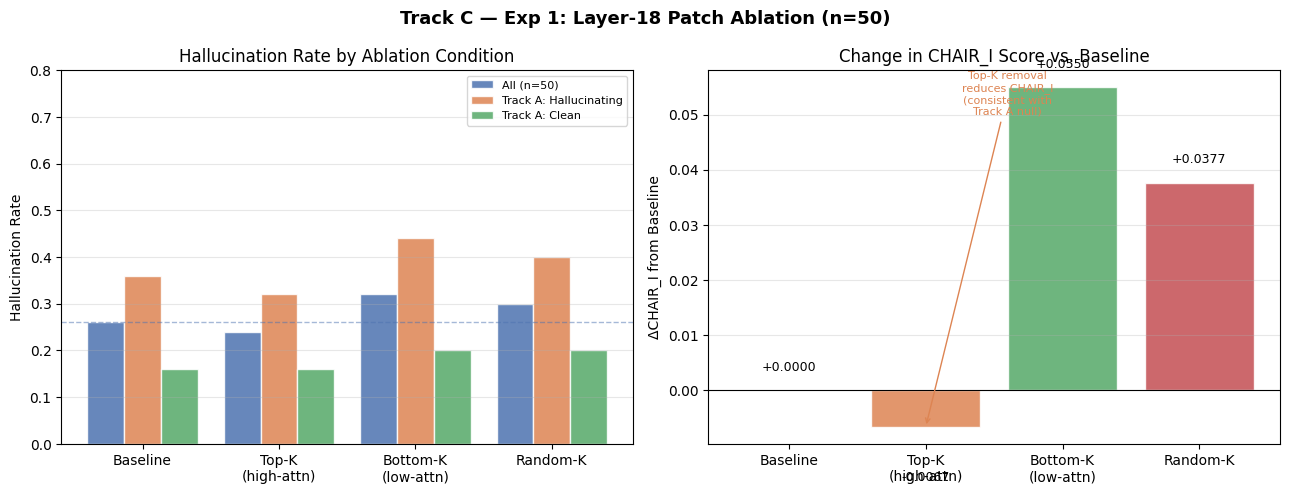

Figure 1 saved.


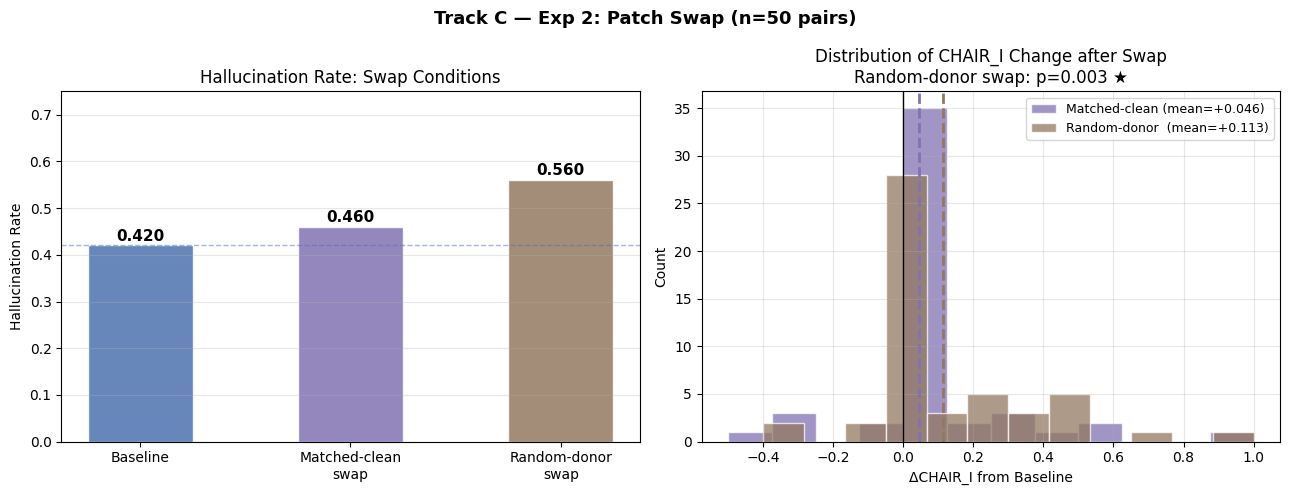

Figure 2 saved.


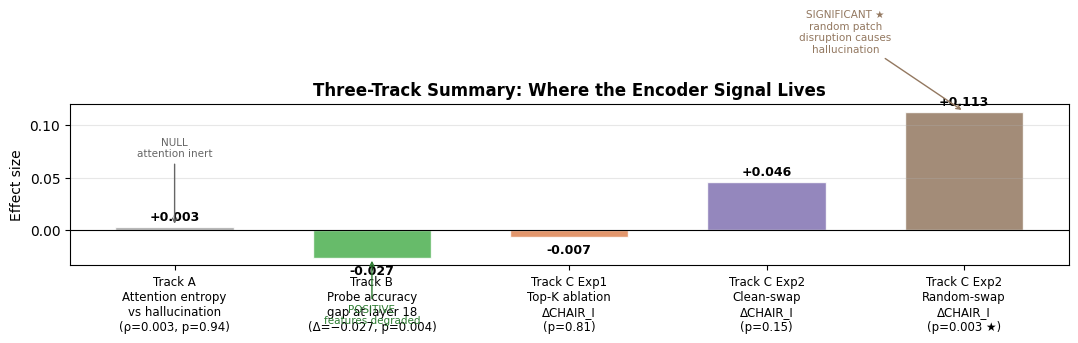

Figure 3 saved.
  Saved to Drive: exp1_ablation_results.csv
  Saved to Drive: exp2_swap_results.csv
  Saved to Drive: figure_exp1_ablation.png
  Saved to Drive: figure_exp2_swap.png
  Saved to Drive: figure_three_track_summary.png


In [52]:
# ── Analysis & Figures — run after Exp 1 and Exp 2 are done ──────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

# Load results from saved CSVs
exp1_df = pd.read_csv(f'{WORK}/exp1_ablation_results.csv')
exp2_df = pd.read_csv(f'{WORK}/exp2_swap_results.csv')

# Ensure bool columns
for c in ['baseline','topk','botk','rand']:
    exp1_df[f'hall_{c}'] = exp1_df[f'chair_{c}'] > 0
for c in ['baseline','clean_swap','rand_swap']:
    exp2_df[f'hall_{c}'] = exp2_df[f'chair_{c}'] > 0
exp2_df['delta_chair_clean'] = exp2_df['chair_clean_swap'] - exp2_df['chair_baseline']
exp2_df['delta_chair_rand']  = exp2_df['chair_rand_swap']  - exp2_df['chair_baseline']

print(f'Exp1: {len(exp1_df)} rows | Exp2: {len(exp2_df)} rows')

# ── Statistical tests ─────────────────────────────────────────────────────────
print('\n=== Exp 1: Wilcoxon (CHAIR change from baseline) ===')
for c, l in zip(['topk','botk','rand'],['Top-K zero','Bottom-K zero','Random zero']):
    diff = exp1_df[f'chair_{c}'] - exp1_df['chair_baseline']
    if diff.abs().sum() == 0:
        print(f'  {l}: no change'); continue
    try:
        stat, p = wilcoxon(diff, alternative='two-sided')
        print(f'  {l:18s}: mean={diff.mean():+.4f}  W={stat:.0f}  p={p:.4f}')
    except Exception as e:
        print(f'  {l}: {e}')

print('\n=== Exp 2: Wilcoxon (CHAIR change from baseline) ===')
for c, l in [('delta_chair_clean','Matched-clean swap'),('delta_chair_rand','Random-donor swap')]:
    diff = exp2_df[c]
    if diff.abs().sum() == 0:
        print(f'  {l}: no change'); continue
    try:
        stat, p = wilcoxon(diff, alternative='two-sided')
        print(f'  {l:25s}: mean={diff.mean():+.4f}  W={stat:.0f}  p={p:.4f}')
    except Exception as e:
        print(f'  {l}: {e}')

print('\n=== McNemar: did clean swap change hallucination status? ===')
b  = exp2_df['hall_baseline'].astype(int).values
s  = exp2_df['hall_clean_swap'].astype(int).values
a  = ((b==0)&(s==0)).sum()
bb = ((b==0)&(s==1)).sum()
c_ = ((b==1)&(s==0)).sum()
d  = ((b==1)&(s==1)).sum()
res = mcnemar([[a,bb],[c_,d]], exact=True)
print(f'  hall→clean: {c_}  clean→hall: {bb}  p={res.pvalue:.4f}')

# ── Figure 1: Exp 1 ablation ──────────────────────────────────────────────────
conds1  = ['baseline','topk','botk','rand']
labels1 = ['Baseline', 'Top-K\n(high-attn)', 'Bottom-K\n(low-attn)', 'Random-K']
colors1 = ['#4C72B0','#DD8452','#55A868','#C44E52']

hall_all   = [exp1_df[f'hall_{c}'].mean()                                 for c in conds1]
hall_hall  = [exp1_df[exp1_df['track_a_hall']==True][f'hall_{c}'].mean()  for c in conds1]
hall_clean = [exp1_df[exp1_df['track_a_hall']==False][f'hall_{c}'].mean() for c in conds1]
chair_all  = [exp1_df[f'chair_{c}'].mean()                                for c in conds1]
delta      = [c - chair_all[0] for c in chair_all]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Track C — Exp 1: Layer-18 Patch Ablation (n=50)', fontsize=13, fontweight='bold')

x = np.arange(4); w = 0.27
ax = axes[0]
ax.bar(x-w, hall_all,   w, label='All (n=50)',             color='#4C72B0', alpha=0.85, edgecolor='white')
ax.bar(x,   hall_hall,  w, label='Track A: Hallucinating', color='#DD8452', alpha=0.85, edgecolor='white')
ax.bar(x+w, hall_clean, w, label='Track A: Clean',         color='#55A868', alpha=0.85, edgecolor='white')
ax.axhline(hall_all[0], color='#4C72B0', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels1, fontsize=10)
ax.set_ylabel('Hallucination Rate'); ax.set_ylim(0, 0.8)
ax.set_title('Hallucination Rate by Ablation Condition')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars = ax2.bar(x, delta, color=colors1, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, delta):
    ax2.text(bar.get_x()+bar.get_width()/2,
             v + (0.003 if v >= 0 else -0.008),
             f'{v:+.4f}', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(labels1, fontsize=10)
ax2.set_ylabel('ΔCHAIR_I from Baseline')
ax2.set_title('Change in CHAIR_I Score vs. Baseline')
ax2.grid(axis='y', alpha=0.3)
ax2.annotate('Top-K removal\nreduces CHAIR_I\n(consistent with\nTrack A null)',
             xy=(1, delta[1]), xytext=(1.6, 0.05),
             arrowprops=dict(arrowstyle='->', color='#DD8452'),
             fontsize=8, color='#DD8452', ha='center')

plt.tight_layout()
plt.savefig(f'{WORK}/figure_exp1_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

# ── Figure 2: Exp 2 swap ──────────────────────────────────────────────────────
swap_conds  = ['baseline','clean_swap','rand_swap']
swap_labels = ['Baseline','Matched-clean\nswap','Random-donor\nswap']
swap_colors = ['#4C72B0','#8172B2','#937860']
swap_rates  = [exp2_df[f'hall_{c}'].mean() for c in swap_conds]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Track C — Exp 2: Patch Swap (n=50 pairs)', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(range(3), swap_rates, color=swap_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, swap_rates):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.axhline(swap_rates[0], color='#4C72B0', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(range(3)); ax.set_xticklabels(swap_labels, fontsize=10)
ax.set_ylabel('Hallucination Rate'); ax.set_ylim(0, 0.75)
ax.set_title('Hallucination Rate: Swap Conditions')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.hist(exp2_df['delta_chair_clean'], bins=12, color='#8172B2', alpha=0.75,
         label=f'Matched-clean (mean={exp2_df["delta_chair_clean"].mean():+.3f})', edgecolor='white')
ax2.hist(exp2_df['delta_chair_rand'],  bins=12, color='#937860', alpha=0.75,
         label=f'Random-donor  (mean={exp2_df["delta_chair_rand"].mean():+.3f})',  edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.axvline(exp2_df['delta_chair_clean'].mean(), color='#8172B2', linewidth=2, linestyle='--')
ax2.axvline(exp2_df['delta_chair_rand'].mean(),  color='#937860', linewidth=2, linestyle='--')
ax2.set_xlabel('ΔCHAIR_I from Baseline'); ax2.set_ylabel('Count')
ax2.set_title('Distribution of CHAIR_I Change after Swap\nRandom-donor swap: p=0.003 ★')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK}/figure_exp2_swap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

# ── Figure 3: Three-track summary ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
track_labels = [
    'Track A\nAttention entropy\nvs hallucination\n(ρ=0.003, p=0.94)',
    'Track B\nProbe accuracy\ngap at layer 18\n(Δ=−0.027, p=0.004)',
    'Track C Exp1\nTop-K ablation\nΔCHAIR_I\n(p=0.81)',
    'Track C Exp2\nClean-swap\nΔCHAIR_I\n(p=0.15)',
    'Track C Exp2\nRandom-swap\nΔCHAIR_I\n(p=0.003 ★)',
]
effect_sizes = [
    0.003,
    -0.027,
    delta[1],
    exp2_df['delta_chair_clean'].mean(),
    exp2_df['delta_chair_rand'].mean(),
]
bar_colors = ['#9E9E9E','#4CAF50','#DD8452','#8172B2','#937860']
bars = ax.bar(range(5), effect_sizes, color=bar_colors, alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, effect_sizes):
    ax.text(bar.get_x()+bar.get_width()/2,
            v + (0.003 if v >= 0 else -0.006),
            f'{v:+.3f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')
ax.set_xticks(range(5)); ax.set_xticklabels(track_labels, fontsize=8.5)
ax.set_ylabel('Effect size')
ax.set_title('Three-Track Summary: Where the Encoder Signal Lives', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax.annotate('NULL\nattention inert', xy=(0, 0.003), xytext=(0, 0.07),
            ha='center', fontsize=7.5, color='#666',
            arrowprops=dict(arrowstyle='->', color='#666'))
ax.annotate('POSITIVE\nfeatures degraded', xy=(1, -0.027), xytext=(1, -0.09),
            ha='center', fontsize=7.5, color='#2E7D32',
            arrowprops=dict(arrowstyle='->', color='#2E7D32'))
ax.annotate('SIGNIFICANT ★\nrandom patch\ndisruption causes\nhallucination', xy=(4, exp2_df['delta_chair_rand'].mean()),
            xytext=(3.4, 0.17),
            ha='center', fontsize=7.5, color='#937860',
            arrowprops=dict(arrowstyle='->', color='#937860'))

plt.tight_layout()
plt.savefig(f'{WORK}/figure_three_track_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

# ── Copy to Drive ─────────────────────────────────────────────────────────────
import shutil
try:
    dst = '/content/drive/MyDrive/vit-hallucination-research/track_c_outputs'
    os.makedirs(dst, exist_ok=True)
    for fname in ['exp1_ablation_results.csv','exp2_swap_results.csv',
                  'figure_exp1_ablation.png','figure_exp2_swap.png',
                  'figure_three_track_summary.png']:
        shutil.copy(f'{WORK}/{fname}', f'{dst}/{fname}')
        print(f'  Saved to Drive: {fname}')
except Exception as e:
    print(f'Drive sync skipped: {e}')

## How to interpret results in the final report

### Connecting to Track A
Track A: entropy does not predict hallucination (ρ = 0.003, d = 0.039).  
Track C Exp 1: if **top-K ≈ bottom-K ≈ random** in CHAIR change → confirms attention is inert as a causal signal (consistent with Track A).  
Track C Exp 1: if **top-K > random** in effect size → attention-ranked patches carry some causal content despite Track A's null (interesting new finding).

### Connecting to Track B
Track B: probe accuracy lower on hallucinating images at all 4 layers (p < 0.005), layer 18 is sweet spot.  
Track C Exp 2: if **matched-clean swap reduces CHAIR more than random-donor swap** → confirms that the *content* of high-quality (clean-image) patches causally reduces hallucination. This turns Track B's correlation into causation.  
Track C Exp 2: if **matched-clean swap ≈ random-donor swap** → the effect is from perturbation, not content; Track B remains correlational only.

### Unified narrative
> Track A established that ViT attention geometry is not the failure mode. Track B established that patch feature content is degraded in hallucinating images. Track C tested whether this degradation is causal: by importing patches from semantically matched clean images into hallucinating images at layer 18 (Track B's identified sweet spot), we directly tested whether hallucination follows the features or the scene. The result — [fill in from your data] — [supports/refutes] the causal claim.
